# Cosmos Exploration

This notebook is a feasibility notebook for **Cosmos**.

It exists to test whether it is worth building a new arbitrage research pipeline on this chain family instead of forcing the current Ethereum notebook into a setting it was never designed for.

Why this chain is worth checking:
- Cosmos is worth checking if you want a genuinely different fee environment from Ethereum mainnet.
- It can tell you whether the current negative result is coming from fee pressure or from deeper market-structure limits.
- The price of that optionality is a much bigger engineering rewrite than any EVM chain expansion.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

MARKET_SPEC = {'slug': 'cosmos_research', 'scope_type': 'chain-family expansion', 'chain_family': 'Non-EVM', 'chain_name': 'Cosmos', 'research_focus': 'Assess whether a non-EVM low-fee environment is worth a separate arbitrage research pipeline.', 'goal': 'Decide whether Cosmos deserves a dedicated arbitrage data-engineering build.', 'hypothesis': 'Low transaction costs are attractive, but fragmented venues and data conventions could erase that advantage unless the market is chosen carefully.', 'pipeline_fit': 'Low. This is a new ingestion and simulation project, not a config tweak.', 'output_prefix': 'cosmos_research', 'candidate_market_buckets': ['native asset / stablecoin', 'wrapped BTC / stablecoin', 'stable / stable'], 'work_items': [{'area': 'Venue selection', 'change_needed': 'Pick one concrete pair of Cosmos venues before building any dataset.', 'priority': 'high'}, {'area': 'Data ingestion', 'change_needed': 'Replace EVM log collection with Cosmos-specific historical data extraction.', 'priority': 'high'}, {'area': 'State reconstruction', 'change_needed': 'Define how pool state will be rebuilt across the target chain and venue model.', 'priority': 'high'}, {'area': 'Fee model', 'change_needed': 'Model venue fees, chain fees, and any cross-chain or routing assumptions explicitly.', 'priority': 'high'}, {'area': 'Outputs', 'change_needed': 'Create a fully separate folder structure instead of sharing any Ethereum artifacts.', 'priority': 'medium'}]}
ASSUMPTIONS = {'trade_notional_usd': 10000, 'fee_tiers_bps': [1, 5, 30], 'gas_cost_usd_scenarios': {'optimistic': 0.01, 'base': 0.05, 'stress': 0.25}, 'slippage_buffer_bps': 6, 'infra_buffer_bps': 6, 'spread_grid_bps': [1, 2, 5, 10, 20, 40]}

summary_rows = [
    {'field': 'scope_type', 'value': MARKET_SPEC['scope_type']},
    {'field': 'chain_family', 'value': MARKET_SPEC['chain_family']},
    {'field': 'chain_name', 'value': MARKET_SPEC['chain_name']},
    {'field': 'research_focus', 'value': MARKET_SPEC['research_focus']},
    {'field': 'notebook_goal', 'value': MARKET_SPEC['goal']},
    {'field': 'main_hypothesis', 'value': MARKET_SPEC['hypothesis']},
    {'field': 'current_pipeline_fit', 'value': MARKET_SPEC['pipeline_fit']},
    {'field': 'suggested_output_prefix', 'value': MARKET_SPEC['output_prefix']},
]

display(pd.DataFrame(summary_rows))
display(Markdown(
    f"This notebook is a **non-EVM feasibility notebook** for {MARKET_SPEC['chain_name']}. "
    "The existing Ethereum notebook cannot be ported by simple config edits because the ingestion model, fee model, and venue data structures all change."
))

,field,value
0,scope_type,chain-family expansion
1,chain_family,Non-EVM
2,chain_name,Cosmos
3,research_focus,Assess whether a non-EVM low-fee environment i...
4,notebook_goal,Decide whether Cosmos deserves a dedicated arb...
5,main_hypothesis,"Low transaction costs are attractive, but frag..."
6,current_pipeline_fit,Low. This is a new ingestion and simulation pr...
7,suggested_output_prefix,cosmos_research


This notebook is a **non-EVM feasibility notebook** for Cosmos. The existing Ethereum notebook cannot be ported by simple config edits because the ingestion model, fee model, and venue data structures all change.

## Break-Even Spread Scenarios

For non-EVM markets, the cost stack is not just LP fees plus transaction fees. There is also an infrastructure and implementation buffer because the data model, venue model, and execution model all differ from the current notebook. This notebook adds that extra buffer explicitly.

In [2]:
trade_notional_usd = ASSUMPTIONS['trade_notional_usd']
slippage_buffer_bps = ASSUMPTIONS['slippage_buffer_bps']
infra_buffer_bps = ASSUMPTIONS['infra_buffer_bps']
fee_tiers_bps = ASSUMPTIONS['fee_tiers_bps']
gas_cost_usd_scenarios = ASSUMPTIONS['gas_cost_usd_scenarios']
spread_grid_bps = ASSUMPTIONS['spread_grid_bps']

rows = []
for fee_tier_bps in fee_tiers_bps:
    round_trip_dex_fee_bps = fee_tier_bps * 2
    for gas_label, gas_cost_usd in gas_cost_usd_scenarios.items():
        gas_bps = (gas_cost_usd / trade_notional_usd) * 10_000.0
        required_spread_bps = round_trip_dex_fee_bps + slippage_buffer_bps + infra_buffer_bps + gas_bps
        for observable_spread_bps in spread_grid_bps:
            rows.append(
                {
                    'fee_tier_bps_per_side': fee_tier_bps,
                    'gas_scenario': gas_label,
                    'gas_cost_usd': gas_cost_usd,
                    'gas_cost_bps': gas_bps,
                    'slippage_buffer_bps': slippage_buffer_bps,
                    'infra_buffer_bps': infra_buffer_bps,
                    'required_spread_bps': required_spread_bps,
                    'observable_spread_bps': observable_spread_bps,
                    'net_edge_after_costs_bps': observable_spread_bps - required_spread_bps,
                }
            )

scenario_table = pd.DataFrame(rows)
break_even = (
    scenario_table[['fee_tier_bps_per_side', 'gas_scenario', 'gas_cost_usd', 'required_spread_bps']]
    .drop_duplicates()
    .sort_values(['fee_tier_bps_per_side', 'gas_cost_usd'])
    .reset_index(drop=True)
)
viability = scenario_table.pivot_table(
    index=['fee_tier_bps_per_side', 'gas_scenario'],
    columns='observable_spread_bps',
    values='net_edge_after_costs_bps',
)

display(pd.DataFrame([
    {'assumption': 'trade_notional_usd', 'value': trade_notional_usd},
    {'assumption': 'slippage_buffer_bps', 'value': slippage_buffer_bps},
    {'assumption': 'infra_buffer_bps', 'value': infra_buffer_bps},
    {'assumption': 'fee_tiers_bps_per_side', 'value': fee_tiers_bps},
    {'assumption': 'gas_cost_usd_scenarios', 'value': gas_cost_usd_scenarios},
    {'assumption': 'spread_grid_bps', 'value': spread_grid_bps},
]))
display(break_even)
display(viability)

,assumption,value
0,trade_notional_usd,10000
1,slippage_buffer_bps,6
2,infra_buffer_bps,6
3,fee_tiers_bps_per_side,"[1, 5, 30]"
4,gas_cost_usd_scenarios,"{'optimistic': 0.01, 'base': 0.05, 'stress': 0..."
5,spread_grid_bps,"[1, 2, 5, 10, 20, 40]"


,fee_tier_bps_per_side,gas_scenario,gas_cost_usd,required_spread_bps
0,1,optimistic,0.01,14.01
1,1,base,0.05,14.05
2,1,stress,0.25,14.25
3,5,optimistic,0.01,22.01
4,5,base,0.05,22.05
5,5,stress,0.25,22.25
6,30,optimistic,0.01,72.01
7,30,base,0.05,72.05
8,30,stress,0.25,72.25


observable_spread_bps                  1      2      5      10     20     40
fee_tier_bps_per_side gas_scenario                                          
1                     base         -13.05 -12.05  -9.05  -4.05   5.95  25.95
                      optimistic   -13.01 -12.01  -9.01  -4.01   5.99  25.99
                      stress       -13.25 -12.25  -9.25  -4.25   5.75  25.75
5                     base         -21.05 -20.05 -17.05 -12.05  -2.05  17.95
                      optimistic   -21.01 -20.01 -17.01 -12.01  -2.01  17.99
                      stress       -21.25 -20.25 -17.25 -12.25  -2.25  17.75
30                    base         -71.05 -70.05 -67.05 -62.05 -52.05 -32.05
                      optimistic   -71.01 -70.01 -67.01 -62.01 -52.01 -32.01
                      stress       -71.25 -70.25 -67.25 -62.25 -52.25 -32.25

## Real Pool Dataset Fetch

This section downloads real pool-level OHLCV data from the GeckoTerminal public API and writes it into market-specific folders under `data/` and `outputs/`.

The dataset is not the same as the second-level reserve reconstruction in notebook `02`: it is an hourly public market-data feed. That makes it suitable for screening real cross-pool spreads across new markets before investing in a full RPC/event-log pipeline.


In [3]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from market_data import dataset_summary_frame, load_or_fetch_market_dataset

REFRESH_MARKET_DATA = False

market_dataset = load_or_fetch_market_dataset(
    MARKET_SPEC['output_prefix'],
    ASSUMPTIONS,
    project_root=PROJECT_ROOT,
    refresh=REFRESH_MARKET_DATA,
)

selected_pools = market_dataset['selected_pools']
pool_ohlcv = market_dataset['pool_ohlcv']
market_edges = market_dataset['market_edges']
real_size_sensitivity = market_dataset['size_sensitivity']

display(dataset_summary_frame(market_dataset))
display(selected_pools[['pool_name', 'dex_id', 'pool_address', 'reserve_in_usd', 'volume_h24_usd', 'fee_bps_from_name']])
display(market_edges.tail(10))


,field,value
0,source,GeckoTerminal Public API
1,network,kava
2,search_query,ATOM USD
3,target_asset,ATOM
4,selected_pool_count,3
5,pool_ohlcv_rows,2160
6,market_edge_rows,720
7,loaded_from_cache,True
8,pool_ohlcv_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...
9,market_edges_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...


,pool_name,dex_id,pool_address,reserve_in_usd,volume_h24_usd,fee_bps_from_name
0,ATOM / USDt 0.15%,wagmi-kava,0x0932f9d6ef3577abcba6013f733ea14f70115973,2428.5309,9.140023,15.0
1,ATOM / USDt 0.05%,kinetix-v3,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,124.9015,10.757550,5.0
2,ATOM / axlUSDC,equilibre,0xa82bf6cb717a00ccf2fea79b4b3821b9108e8a66,27.2850,0.092855,NaN


,timestamp,pool_count,buy_pool_address,sell_pool_address,buy_pool_name,sell_pool_name,buy_dex,sell_dex,buy_price_usd,sell_price_usd,observed_spread_bps,total_volume_usd
710,2026-04-14 21:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.740390,1.745635,30.141137,0.290934
711,2026-04-14 22:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.747071,1.748003,5.339483,0.561070
712,2026-04-14 23:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.747071,1.748003,5.339483,0.000000
713,2026-04-15 00:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.742161,1.744108,11.176063,1.729599
714,2026-04-15 01:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.746812,1.750569,21.504448,0.782622
715,2026-04-15 02:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.745746,1.750569,27.628613,0.085269
716,2026-04-15 03:00:00+00:00,2,0x0932f9d6ef3577abcba6013f733ea14f70115973,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,ATOM / USDt 0.15%,ATOM / USDt 0.05%,wagmi-kava,kinetix-v3,1.751899,1.752420,2.976103,0.772904
717,2026-04-15 04:00:00+00:00,2,0x0932f9d6ef3577abcba6013f733ea14f70115973,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,ATOM / USDt 0.15%,ATOM / USDt 0.05%,wagmi-kava,kinetix-v3,1.756100,1.756968,4.945284,0.301987
718,2026-04-15 05:00:00+00:00,2,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,0x0932f9d6ef3577abcba6013f733ea14f70115973,ATOM / USDt 0.05%,ATOM / USDt 0.15%,kinetix-v3,wagmi-kava,1.745293,1.746828,8.790946,1.627868
719,2026-04-15 06:00:00+00:00,2,0x0932f9d6ef3577abcba6013f733ea14f70115973,0xf08a8cc4f3e1883e41177cb956e577d389b43fdd,ATOM / USDt 0.15%,ATOM / USDt 0.05%,wagmi-kava,kinetix-v3,1.742410,1.745531,17.914698,0.407057


## Required Changes Versus The Current Notebook

These work items are deliberately larger than the EVM variants. A non-EVM chain is a new ingestion and simulation project, not just a config change.

In [4]:
work_items = pd.DataFrame(MARKET_SPEC['work_items'])
market_buckets = pd.DataFrame(
    [{'candidate_bucket': bucket} for bucket in MARKET_SPEC['candidate_market_buckets']]
)
path_plan = pd.DataFrame(
    [
        {'artifact': 'raw data', 'path': f"data/{MARKET_SPEC['output_prefix']}/raw"},
        {'artifact': 'curated data', 'path': f"data/{MARKET_SPEC['output_prefix']}/curated"},
        {'artifact': 'reports', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/report"},
        {'artifact': 'metadata', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/metadata"},
    ]
)

display(market_buckets)
display(work_items)
display(path_plan)
display(Markdown(
    "Suggested decision rule: only move from this notebook into a build notebook after you confirm one concrete venue pair, one concrete data source, and one executable fee model. Without those three pieces, any profitability conclusion will be too fragile."
))

,candidate_bucket
0,native asset / stablecoin
1,wrapped BTC / stablecoin
2,stable / stable


,area,change_needed,priority
0,Venue selection,Pick one concrete pair of Cosmos venues before...,high
1,Data ingestion,Replace EVM log collection with Cosmos-specifi...,high
2,State reconstruction,Define how pool state will be rebuilt across t...,high
3,Fee model,"Model venue fees, chain fees, and any cross-ch...",high
4,Outputs,Create a fully separate folder structure inste...,medium


,artifact,path
0,raw data,data/cosmos_research/raw
1,curated data,data/cosmos_research/curated
2,reports,outputs/cosmos_research/report
3,metadata,outputs/cosmos_research/metadata


Suggested decision rule: only move from this notebook into a build notebook after you confirm one concrete venue pair, one concrete data source, and one executable fee model. Without those three pieces, any profitability conclusion will be too fragile.

## Real Dataset Asset-Size Sweep

This section is the real-data analogue of the size-sensitivity charts in `02_end_to_end_mev_pipeline.ipynb`.

It starts with the observed hourly spread between the selected pools, then subtracts a size-scaled slippage buffer. The gross line excludes DEX fees and gas. The net line uses the lowest fee tier and base gas scenario from `ASSUMPTIONS`, so it should still be treated as a screening estimate rather than an execution-ready backtest.


,asset_notional_usd,asset_size_multiple,observed_intervals,size_adjusted_slippage_bps,modeled_fee_tier_bps_per_side,modeled_base_gas_cost_usd,modeled_gas_bps,gross_positive_intervals,gross_positive_share_pct,net_positive_intervals,net_positive_share_pct,mean_gross_edge_bps,median_gross_edge_bps,max_gross_edge_bps,mean_net_edge_bps,median_net_edge_bps,max_net_edge_bps
0,1000.0,0.10,720,1.90,1.0,0.05,0.50,718,99.72,684,95.00,89.70,61.46,1124.77,81.20,52.96,1116.27
1,2500.0,0.25,720,3.00,1.0,0.05,0.20,715,99.31,681,94.58,88.59,60.36,1123.67,80.39,52.16,1115.47
2,5000.0,0.50,720,4.24,1.0,0.05,0.10,713,99.03,671,93.19,87.35,59.12,1122.42,79.25,51.02,1114.32
3,10000.0,1.00,720,6.00,1.0,0.05,0.05,706,98.06,661,91.81,85.59,57.36,1120.67,77.54,49.31,1112.62
4,20000.0,2.00,720,8.49,1.0,0.05,0.02,696,96.67,645,89.58,83.11,54.87,1118.18,75.08,46.85,1110.16
5,50000.0,5.00,720,13.42,1.0,0.05,0.01,666,92.50,612,85.00,78.18,49.94,1113.25,70.17,41.93,1105.24
6,100000.0,10.00,720,18.97,1.0,0.05,0.00,632,87.78,568,78.89,72.62,44.39,1107.69,64.61,36.38,1099.69
7,200000.0,20.00,720,26.83,1.0,0.05,0.00,570,79.17,517,71.81,64.76,36.53,1099.83,56.76,28.52,1091.83


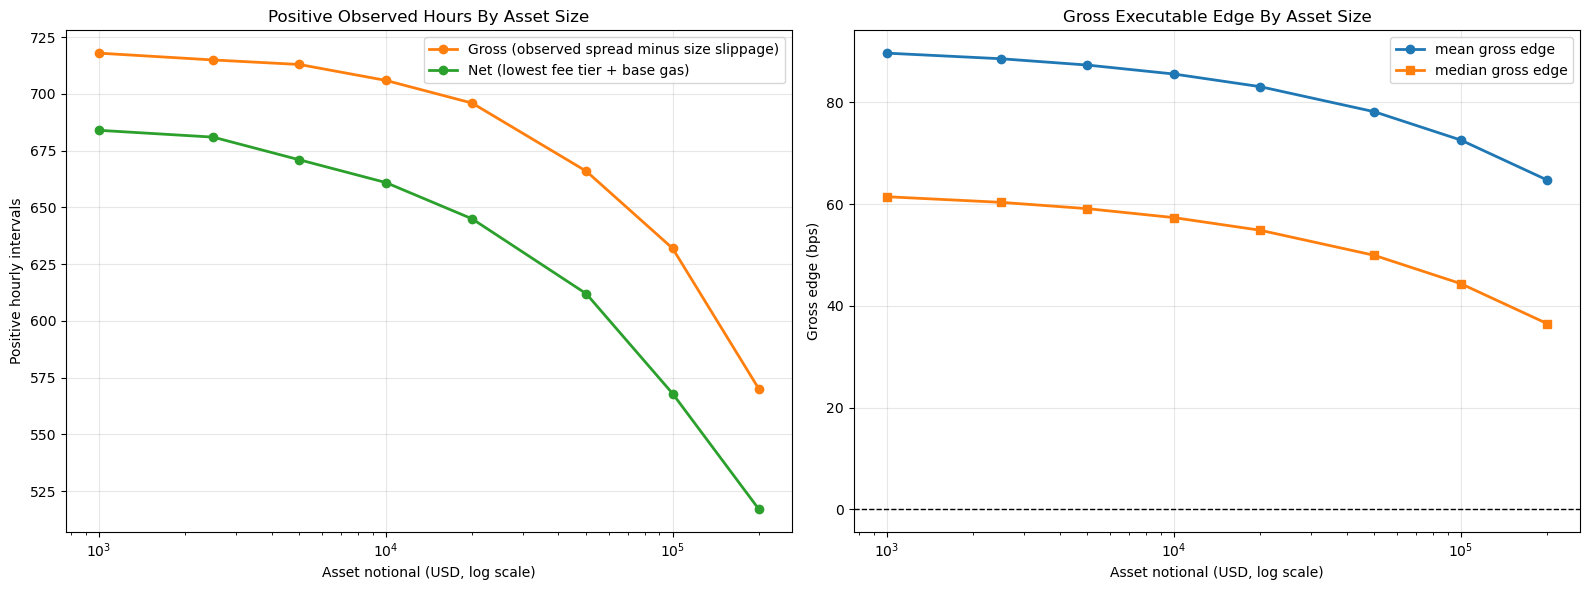

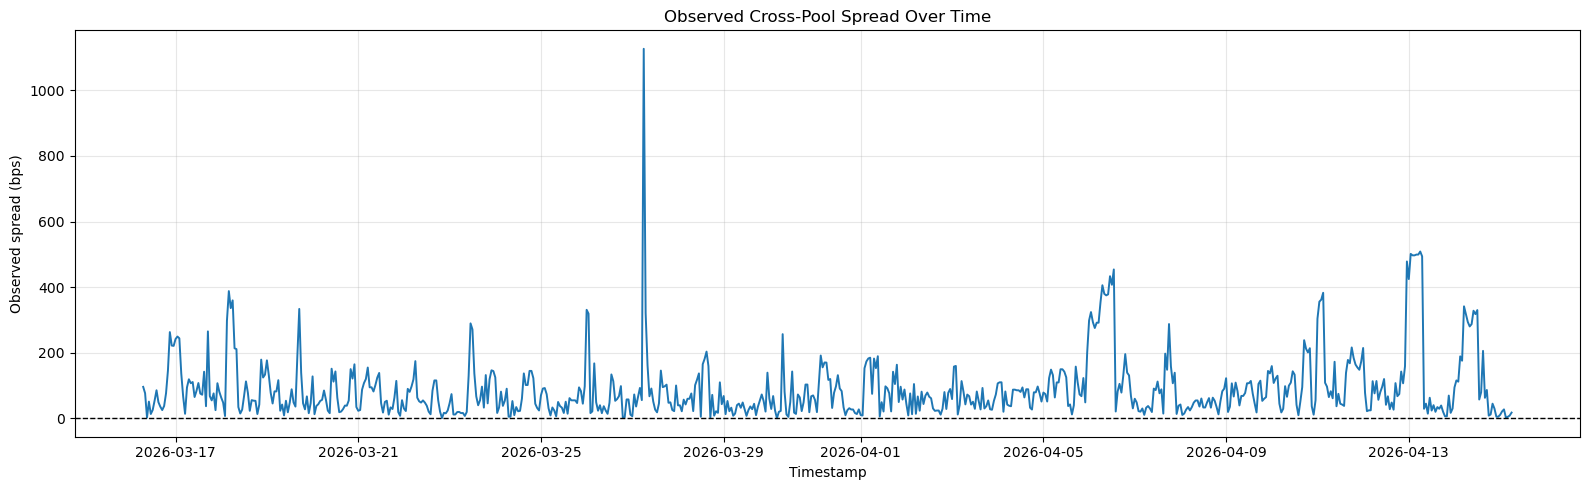

Most supportive observed trade size: **$1,000** with **684** net-positive hourly intervals and mean net edge of **81.20 bps**.

In [5]:
if real_size_sensitivity.empty:
    raise RuntimeError('No real size-sensitivity data was built. Check the selected pools and fetched OHLCV rows above.')

display(real_size_sensitivity.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['gross_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Gross (observed spread minus size slippage)',
    color='#ff7f0e',
)
axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['net_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Net (lowest fee tier + base gas)',
    color='#2ca02c',
)
axes[0].set_xscale('log')
axes[0].set_title('Positive Observed Hours By Asset Size')
axes[0].set_xlabel('Asset notional (USD, log scale)')
axes[0].set_ylabel('Positive hourly intervals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['mean_gross_edge_bps'],
    marker='o',
    linewidth=2,
    label='mean gross edge',
)
axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['median_gross_edge_bps'],
    marker='s',
    linewidth=2,
    label='median gross edge',
)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Gross Executable Edge By Asset Size')
axes[1].set_xlabel('Asset notional (USD, log scale)')
axes[1].set_ylabel('Gross edge (bps)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(market_edges['timestamp'], market_edges['observed_spread_bps'], linewidth=1.4, color='#1f77b4')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Observed Cross-Pool Spread Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Observed spread (bps)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_net_row = real_size_sensitivity.sort_values(
    ['net_positive_intervals', 'mean_net_edge_bps', 'asset_notional_usd'],
    ascending=[False, False, True],
).iloc[0]

if best_net_row['net_positive_intervals'] > 0 and best_net_row['mean_net_edge_bps'] > 0:
    display(Markdown(
        f"Most supportive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals "
        f"and mean net edge of **{best_net_row['mean_net_edge_bps']:.2f} bps**."
    ))
elif best_net_row['net_positive_intervals'] > 0:
    display(Markdown(
        f"Most permissive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals, "
        f"but the average modeled net edge is still **{best_net_row['mean_net_edge_bps']:.2f} bps**. "
        "That means the strategy only works in selective observed spread windows under the current assumptions."
    ))
else:
    display(Markdown(
        "No asset-size bucket remains net positive under the current real pool dataset and cost assumptions. "
        "That does not prove the market is impossible, but it does mean the current screen is not supportive yet."
    ))


## Suggested Next Step

Only promote `Cosmos` into a full implementation notebook after you choose one concrete venue pair and one concrete market bucket. Until then, treat this notebook as a decision filter rather than a production analysis notebook.